## 1 Overview

### 1.1 Problem Statement

### 1.2 About Dataset

### 1.3 Objective

Perform Root Cause Analysis (RCA) to identify the root cause of trip cancellation.

To achieve this objective perform:

1. Exploratory data analysis on dataset.
2. Perform Feature Engineering.
3. Define and analyze Metrics.

## 2 Setup

### 2.1 Libraries

#### Import Libraries

In [1]:
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt
import seaborn as sns

#### Configure Libraries

In [2]:
# Configure NumPy.
np.random.seed(42)

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

#### Constants and Helper Functions

In [3]:
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

### 2.3 Dataset

#### Import dataset

In [4]:
ub_df = pd.read_csv("data/uber-data.csv")

row_count, col_count = ub_df.shape
display(ub_df.sample(5, random_state=16))
print(f"Dataset has {row_count} rows and {col_count} columns.")

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
2898,5208,Airport,20.0,Cancelled,14-07-2016 20:55:57,NaN
326,1478,City,33.0,Trip Completed,12/7/2016 5:16,12/7/2016 6:13
6649,6552,Airport,NaN,No Cars Available,15-07-2016 21:08:54,NaN
1902,6007,City,199.0,Trip Completed,15-07-2016 12:15:42,15-07-2016 13:03:40
4557,1257,Airport,NaN,No Cars Available,11/7/2016 21:55,NaN


Dataset has 6745 rows and 6 columns.


### 2.4 Data Profiling

In [5]:
ub_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 316.3 KB


In [6]:
ub_df.rename(
    columns={
        "Request id": "req_id",
        "Pickup point": "pickup",
        "Driver id": "dvr_id",
        "Status": "status",
        "Request timestamp": "req_dt",
        "Drop timestamp": "drp_dt",
    },
    inplace=True,
)

In [7]:
ub_df["req_id"].nunique()

6745

In [8]:
# ub_df.drop(columns="req_id", inplace=True)

In [9]:
ub_df["pickup"].value_counts()

pickup
City       3507
Airport    3238
Name: count, dtype: int64

In [10]:
ub_df["status"].value_counts()

status
Trip Completed       2831
No Cars Available    2650
Cancelled            1264
Name: count, dtype: int64

In [11]:
ub_df["status"] = ub_df["status"].map(
    {
        "Trip Completed": "Completed",
        "No Cars Available": "Unavailable",
        "Cancelled": "Canceled",
    }
)

In [12]:
ub_df["status"].value_counts()

status
Completed      2831
Unavailable    2650
Canceled       1264
Name: count, dtype: int64

## 3 Data Wrangling

### 3.1 Type Casting

In [13]:
ub_df.loc[[326, 1902, 4557], ["req_dt", "drp_dt"]]

,req_dt,drp_dt
326,12/7/2016 5:16,12/7/2016 6:13
1902,15-07-2016 12:15:42,15-07-2016 13:03:40
4557,11/7/2016 21:55,NaN


In [14]:
ub_df["req_dt"] = pd.to_datetime(ub_df["req_dt"], format="mixed", dayfirst=True)
ub_df["drp_dt"] = pd.to_datetime(ub_df["drp_dt"], format="mixed", dayfirst=True)

In [15]:
ub_df.loc[[326, 1902, 4557], ["req_dt", "drp_dt"]]

,req_dt,drp_dt
326,2016-07-12 05:16:00,2016-07-12 06:13:00
1902,2016-07-15 12:15:42,2016-07-15 13:03:40
4557,2016-07-11 21:55:00,NaT


### 3.2 Data Validation

In [16]:
mask = ub_df["drp_dt"] < ub_df["req_dt"]
ub_df[mask]

,req_id,pickup,dvr_id,status,req_dt,drp_dt


In [17]:
mask = ub_df["drp_dt"].isna()
ub_df[mask]["status"].value_counts()

status
Unavailable    2650
Canceled       1264
Name: count, dtype: int64

In [18]:
mask = ub_df["dvr_id"].isna()
ub_df[mask]["status"].value_counts()

status
Unavailable    2650
Name: count, dtype: int64

## 4 Feature Engineering

### 4.1 Create New Features

#### Extract features from request date-time

In [19]:
ub_df["req_year"] = ub_df["req_dt"].dt.year.astype("Int32")
ub_df["req_month"] = ub_df["req_dt"].dt.month.astype("Int32")
ub_df["req_date"] = ub_df["req_dt"].dt.day.astype("Int32")
ub_df["req_wday"] = ub_df["req_dt"].dt.day_name()
ub_df["req_hour"] = ub_df["req_dt"].dt.hour.astype("Int32")
ub_df["req_min"] = ub_df["req_dt"].dt.minute.astype("Int32")

In [20]:
ub_df[["req_dt", "req_year", "req_month", "req_date", "req_wday", "req_hour", "req_min"]].sample(3)

,req_dt,req_year,req_month,req_date,req_wday,req_hour,req_min
2531,2016-07-13 03:55:10,2016,7,13,Wednesday,3,55
4591,2016-07-11 23:30:00,2016,7,11,Monday,23,30
4127,2016-07-11 03:07:00,2016,7,11,Monday,3,7


#### Extract features from drop date-time

In [21]:
ub_df["drp_year"] = ub_df["drp_dt"].dt.year.astype("Int32")
ub_df["drp_month"] = ub_df["drp_dt"].dt.month.astype("Int32")
ub_df["drp_date"] = ub_df["drp_dt"].dt.day.astype("Int32")
ub_df["drp_wday"] = ub_df["drp_dt"].dt.day_name()
ub_df["drp_hour"] = ub_df["drp_dt"].dt.hour.astype("Int32")
ub_df["drp_min"] = ub_df["drp_dt"].dt.minute.astype("Int32")

In [22]:
ub_df[["drp_dt", "drp_year", "drp_month", "drp_date", "drp_wday", "drp_hour", "drp_min"]].sample(3)

,drp_dt,drp_year,drp_month,drp_date,drp_wday,drp_hour,drp_min
3858,NaT,<NA>,<NA>,<NA>,NaN,<NA>,<NA>
833,2016-07-13 21:43:20,2016,7,13,Wednesday,21,43
3288,NaT,<NA>,<NA>,<NA>,NaN,<NA>,<NA>


#### New Feature 'Time Difference'

In [23]:
ub_df["time_diff"] = ub_df["drp_dt"] - ub_df["req_dt"]
ub_df[["req_dt", "drp_dt", "time_diff"]].sample(3)

,req_dt,drp_dt,time_diff
5139,2016-07-13 02:37:05,NaT,NaT
6165,2016-07-15 00:09:09,NaT,NaT
4852,2016-07-12 18:20:00,NaT,NaT


#### Final DataFrame

In [24]:
ub_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype          
---  ------     --------------  -----          
 0   req_id     6745 non-null   int64          
 1   pickup     6745 non-null   str            
 2   dvr_id     4095 non-null   float64        
 3   status     6745 non-null   str            
 4   req_dt     6745 non-null   datetime64[us] 
 5   drp_dt     2831 non-null   datetime64[us] 
 6   req_year   6745 non-null   Int32          
 7   req_month  6745 non-null   Int32          
 8   req_date   6745 non-null   Int32          
 9   req_wday   6745 non-null   str            
 10  req_hour   6745 non-null   Int32          
 11  req_min    6745 non-null   Int32          
 12  drp_year   2831 non-null   Int32          
 13  drp_month  2831 non-null   Int32          
 14  drp_date   2831 non-null   Int32          
 15  drp_wday   2831 non-null   str            
 16  drp_hour   2831 non-null   Int32   

In [25]:
ub_df.head()

,req_id,pickup,dvr_id,status,req_dt,drp_dt,req_year,req_month,req_date,req_wday,req_hour,req_min,drp_year,drp_month,drp_date,drp_wday,drp_hour,drp_min,time_diff
0,619,Airport,1.0,Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,2016,7,11,Monday,11,51,2016,7,11,Monday,13,0,0 days 01:09:00
1,867,Airport,1.0,Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,2016,7,11,Monday,17,57,2016,7,11,Monday,18,47,0 days 00:50:00
2,1807,City,1.0,Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,2016,7,12,Tuesday,9,17,2016,7,12,Tuesday,9,58,0 days 00:41:00
3,2532,Airport,1.0,Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,2016,7,12,Tuesday,21,8,2016,7,12,Tuesday,22,3,0 days 00:55:00
4,3112,City,1.0,Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,2016,7,13,Wednesday,8,33,2016,7,13,Wednesday,9,25,0 days 00:52:31


In [26]:
ub_df["req_year"].value_counts(), ub_df["drp_year"].value_counts()

(req_year
 2016    6745
 Name: count, dtype: Int64,
 drp_year
 2016    2831
 Name: count, dtype: Int64)

In [27]:
ub_df["req_month"].value_counts(), ub_df["drp_month"].value_counts()

(req_month
 7    6745
 Name: count, dtype: Int64,
 drp_month
 7    2831
 Name: count, dtype: Int64)

In [28]:
# ub_df["req_hour"].value_counts().sort_index()

### 4.2 Define New Metrics

1. Demand-Supply-Gap
2. Availability rate
3. Cancellation rate

In [29]:
def caculate_metrics(df: pd.DataFrame, for_col: str):
    """
    Function to compute metric:
        1. Demand Supply Gap.
        2. Availability rate.
        3. Cancellation rate.
    """
    return (
        df.groupby(by=for_col)
        .agg(
            demand=("req_id", "count"),
            supply=("status", lambda x: (x == "Completed").sum()),
            availability=("status", lambda x: (x != "Unavailable").sum()),
            cancel_count=("status", lambda x: (x == "Canceled").sum()),
        )
        .assign(
            ds_gap=lambda df: ((df["demand"] - df["supply"]) / df["demand"] * 100).round(4),
            avblty_rate=lambda df: (df["availability"] / df["demand"]).round(4),
            cancel_rate=lambda df: (df["cancel_count"] / df["demand"]).round(4),
        )
        .reset_index()
    )

### 4.3 Crate Features for Metrics

#### Daily Metrics

In [30]:
dlm_df = caculate_metrics(ub_df, "req_date")
dlm_df

,req_date,demand,supply,availability,cancel_count,ds_gap,avblty_rate,cancel_rate
0,11,1367,601,863,262,56.0351,0.6313,0.1917
1,12,1307,562,802,240,57.0008,0.6136,0.1836
2,13,1337,577,847,270,56.8437,0.6335,0.2019
3,14,1353,530,782,252,60.8278,0.5780,0.1863
4,15,1381,561,801,240,59.3773,0.5800,0.1738


#### Weekly Metrics

In [31]:
wkm_df = caculate_metrics(ub_df, "req_wday")

wd_cat_type = CategoricalDtype(categories=weekdays, ordered=True)
wkm_df["req_wday"] = wkm_df["req_wday"].astype(wd_cat_type)
wkm_df = wkm_df.sort_values(by="req_wday")

wkm_df

,req_wday,demand,supply,availability,cancel_count,ds_gap,avblty_rate,cancel_rate
1,Monday,1367,601,863,262,56.0351,0.6313,0.1917
3,Tuesday,1307,562,802,240,57.0008,0.6136,0.1836
4,Wednesday,1337,577,847,270,56.8437,0.6335,0.2019
2,Thursday,1353,530,782,252,60.8278,0.5780,0.1863
0,Friday,1381,561,801,240,59.3773,0.5800,0.1738


#### Hourly Metrics

In [32]:
hrm_df = caculate_metrics(ub_df, "req_hour")
hrm_df

,req_hour,demand,supply,availability,cancel_count,ds_gap,avblty_rate,cancel_rate
0,0,99,40,43,3,59.5960,0.4343,0.0303
1,1,85,25,29,4,70.5882,0.3412,0.0471
2,2,99,37,42,5,62.6263,0.4242,0.0505
3,3,92,34,36,2,63.0435,0.3913,0.0217
4,4,203,78,129,51,61.5764,0.6355,0.2512
5,5,445,185,361,176,58.4270,0.8112,0.3955
6,6,398,167,312,145,58.0402,0.7839,0.3643
7,7,406,174,343,169,57.1429,0.8448,0.4163
8,8,423,155,333,178,63.3570,0.7872,0.4208
9,9,431,173,348,175,59.8608,0.8074,0.4060


## 5 Univariate Analysis

### 5.1 Categorical Features

#### Feature Status

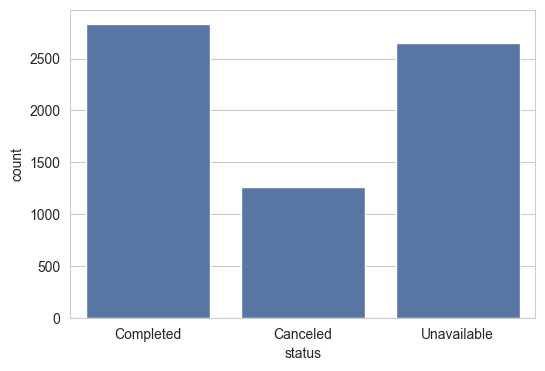

In [33]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="status")
plt.show()

#### Feature Pickup Point

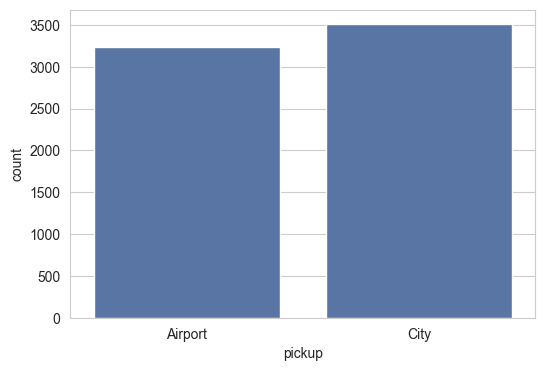

In [34]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="pickup")
plt.show()

### 5.2 Numerical Features

#### Feature Request Date

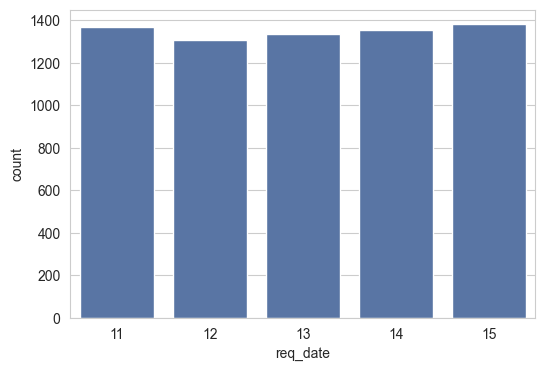

In [35]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="req_date")
plt.show()

#### Feature Request Weekday

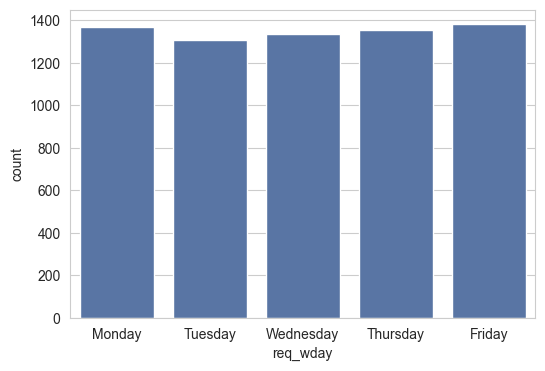

In [36]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="req_wday")
plt.show()

#### Feature Request Hour

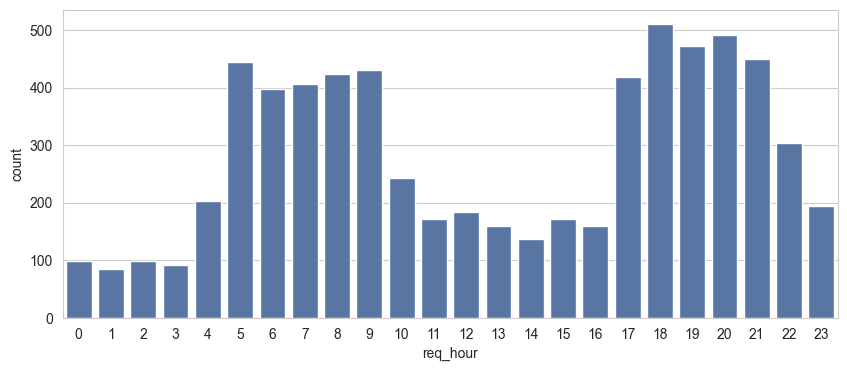

In [37]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="req_hour")
plt.show()

#### Feature Drop Date

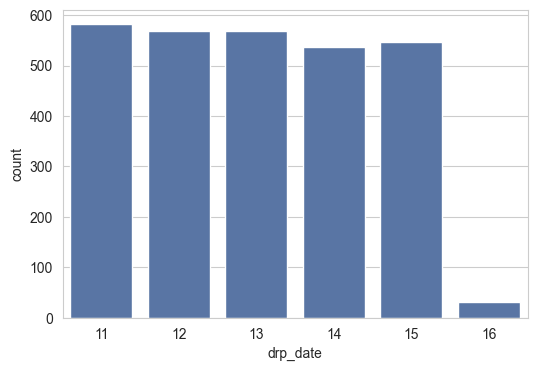

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="drp_date")
plt.show()

#### Feature Drop Weekday

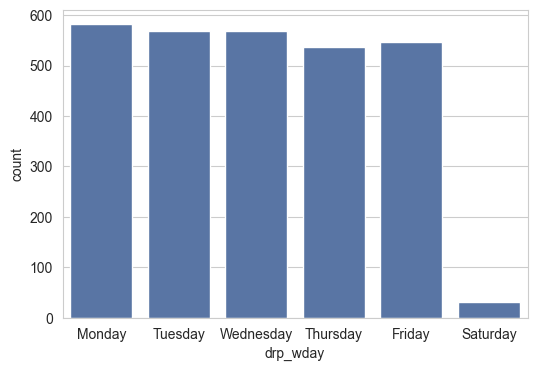

In [39]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="drp_wday")
plt.show()

#### Feature Drop Hour

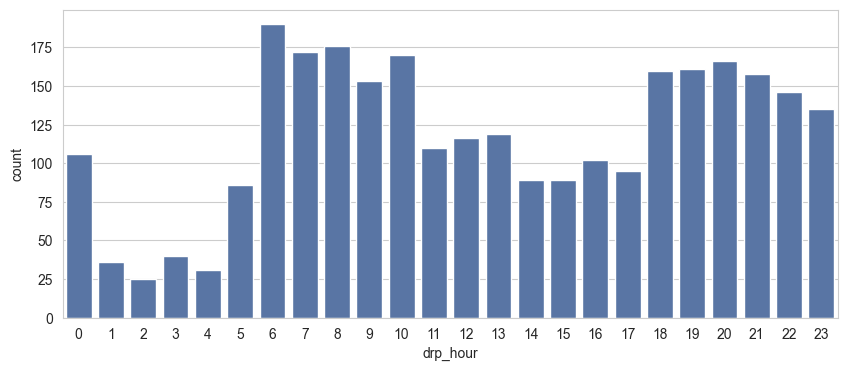

In [40]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="drp_hour")
plt.show()

#### Feature Time Difference

In [41]:
ub_df["time_diff"].dt.total_seconds().describe().to_frame().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
time_diff,2831.00,3144.83,831.04,1247.00,2460.00,3125.00,3840.00,4980.00


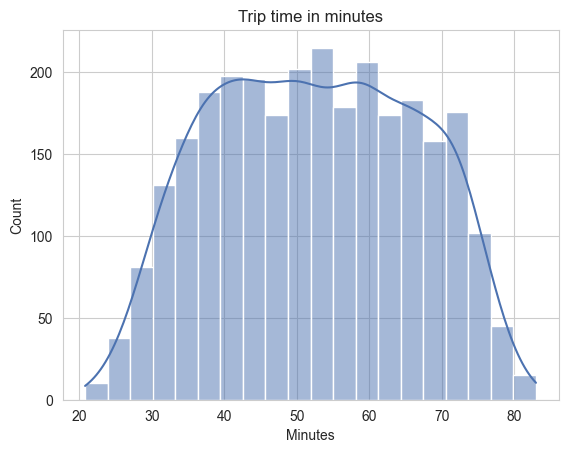

In [42]:
sns.histplot(x=ub_df["time_diff"].dt.total_seconds() / 60, kde=True)
plt.title("Trip time in minutes")
plt.xlabel("Minutes")
plt.show()

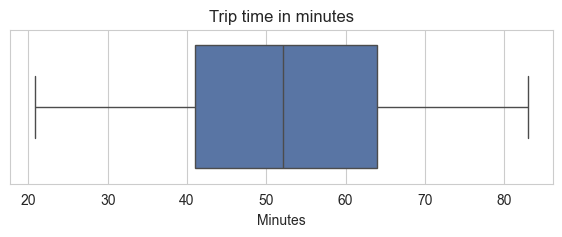

In [43]:
plt.figure(figsize=(7, 2))
sns.boxplot(x=ub_df["time_diff"].dt.total_seconds() / 60)
plt.title("Trip time in minutes")
plt.xlabel("Minutes")
plt.show()

In [44]:
# rd_pt = pd.crosstab(index=ub_df["req_hour"], columns=ub_df["drp_hour"])

# plt.figure(figsize=[12, 10])
# sns.heatmap(rd_pt, cmap="YlGnBu", linecolor="white", linewidth=1, annot=True, fmt=".0f")
# plt.show()

In [45]:
# mask = ~ub_df["drp_hour"].isna()
# rd_pt = ub_df[mask].pivot_table(index="req_hour", columns="drp_hour")
# rd_pt  # Request Drop Pivot table.

#### Feature Daily Cancellation Rate

Frequency of booking requests getting canceled daily between 11th and 15th.

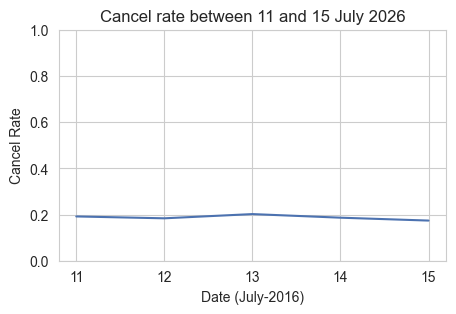

In [46]:
plt.figure(figsize=(5, 3))

sns.lineplot(data=dlm_df, x="req_date", y="cancel_rate")
plt.title("Cancel rate between 11 and 15 July 2026")
plt.xlabel("Date (July-2016)")
plt.ylabel("Cancel Rate")
plt.xticks(range(11, 16))
plt.yticks(np.arange(0, 1.1, 0.2))

plt.show()

#### Feature Weekly Cancellation Rate

Days of week in which the cancellation rate is maximum.

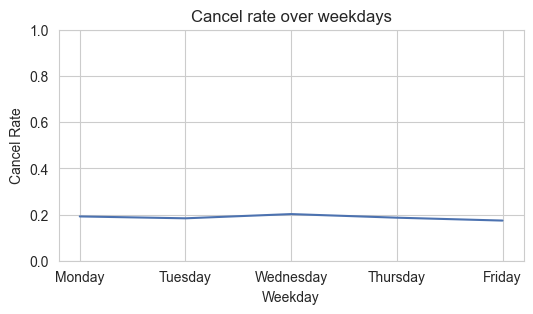

In [47]:
plt.figure(figsize=(6, 3))

sns.lineplot(data=wkm_df, x="req_wday", y="cancel_rate")
plt.title("Cancel rate over weekdays")
plt.xlabel("Weekday")
plt.ylabel("Cancel Rate")
plt.yticks(np.arange(0, 1.1, 0.2))

plt.show()

#### Feature Hourly Cancel Rate

Frequency of booking requests getting canceled every hour.

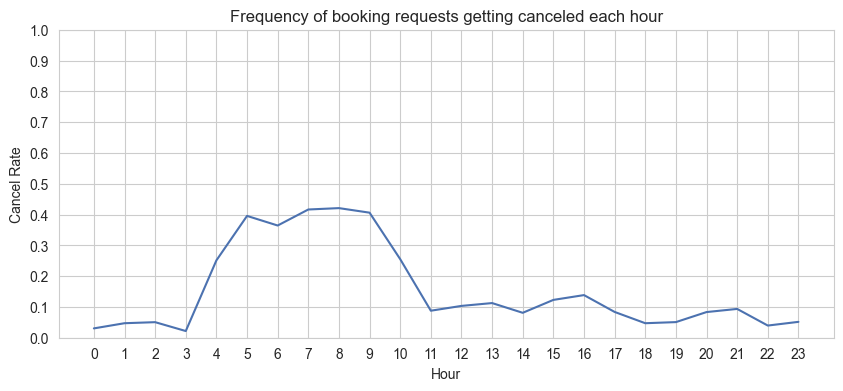

In [48]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=hrm_df, x="req_hour", y="cancel_rate")
plt.title("Frequency of booking requests getting canceled each hour")
plt.xlabel("Hour")
plt.ylabel("Cancel Rate")
plt.xticks(range(0, 24))
plt.yticks(np.arange(0, 1.1, 0.1))

plt.show()

#### Feature Hourly Demand-Supply-Gap

Time of day when the demand is highest and supply is low.

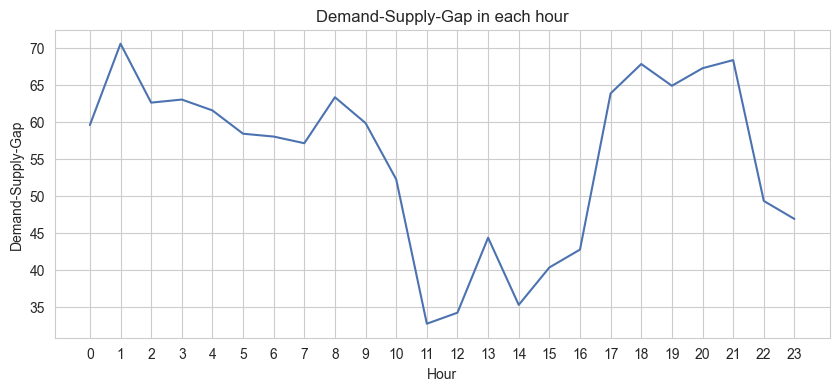

In [49]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=hrm_df, x="req_hour", y="ds_gap")
plt.title("Demand-Supply-Gap in each hour")
plt.xlabel("Hour")
plt.ylabel("Demand-Supply-Gap")
plt.xticks(range(0, 24))

plt.show()

#### Feature Hourly Availability-Supply-Gap

Time of day when the cabs are available but demand is low.

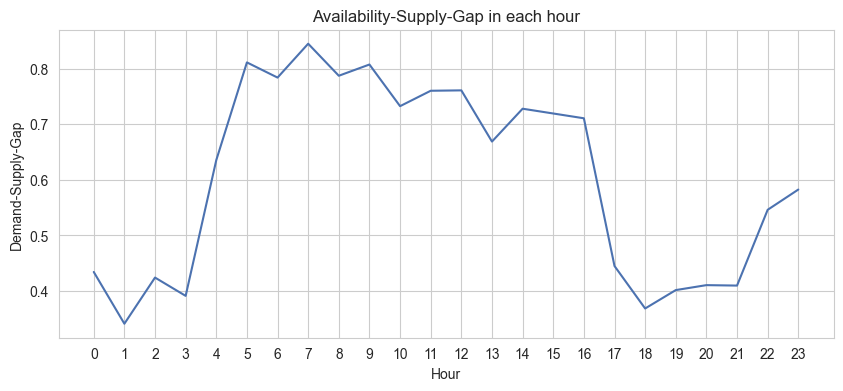

In [50]:
plt.figure(figsize=(10, 4))

sns.lineplot(data=hrm_df, x="req_hour", y="avblty_rate")
plt.title("Availability-Supply-Gap in each hour")
plt.xlabel("Hour")
plt.ylabel("Demand-Supply-Gap")
plt.xticks(range(0, 24))

plt.show()

## 6 Bivariate Analysis

### 6.1 Categorical vs Categorical Features

#### Features `pickup` vs `status`

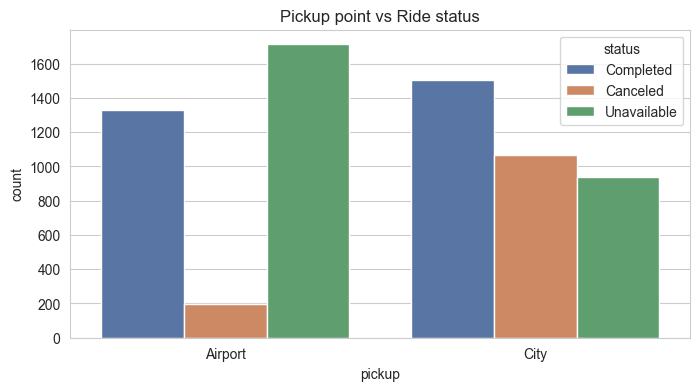

In [51]:
plt.figure(figsize=(8, 4))
sns.countplot(data=ub_df, x="pickup", hue="status")
plt.title("Pickup point vs Ride status")
plt.show()

### 6.2 Numerical Features vs Categorical

#### Features `req_date` vs `status`

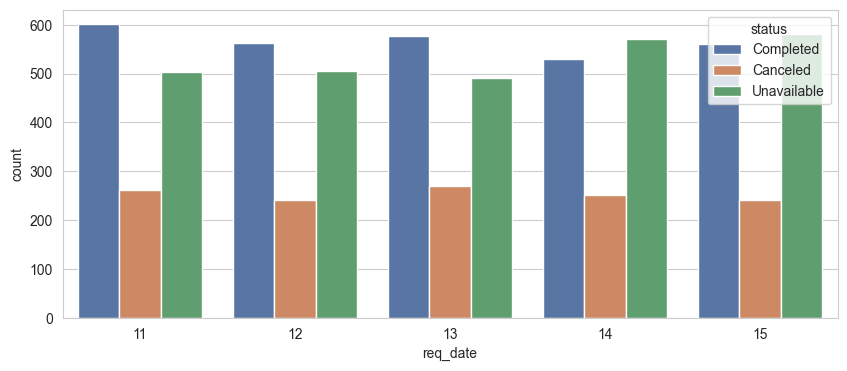

In [52]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="req_date", hue="status")
plt.show()

In [53]:
rdate_status_ct = pd.crosstab(index=ub_df["req_date"], columns=ub_df["status"])
rdate_status_ct

status,Canceled,Completed,Unavailable
req_date,,,
11,262,601,504
12,240,562,505
13,270,577,490
14,252,530,571
15,240,561,580


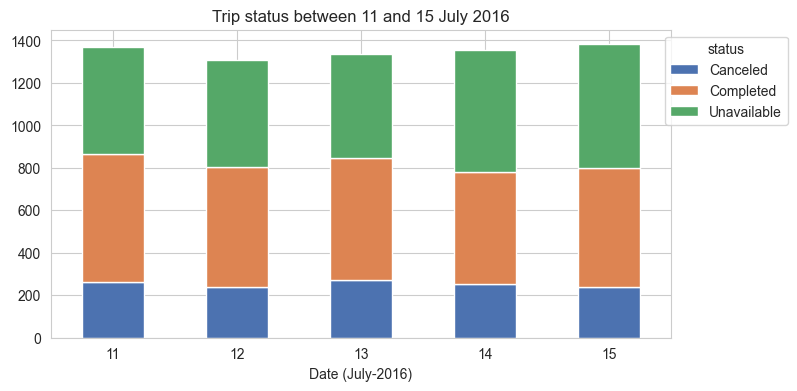

In [54]:
ax = rdate_status_ct.plot(kind="bar", stacked=True, figsize=(8, 4))
ax.legend(title="status", loc="upper right", bbox_to_anchor=(1.2, 1))

plt.title("Trip status between 11 and 15 July 2016")
plt.xlabel("Date (July-2016)")
plt.xticks(rotation=0)

plt.show()

#### Features `req_date` vs `pickup`

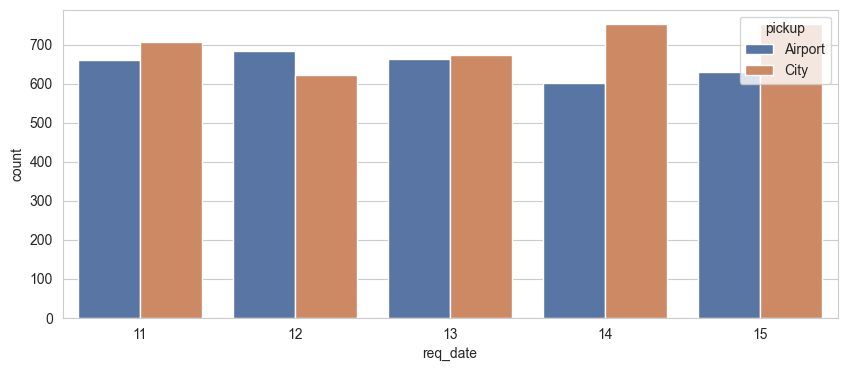

In [55]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="req_date", hue="pickup")
plt.show()

#### Features `req_wday` vs `status`

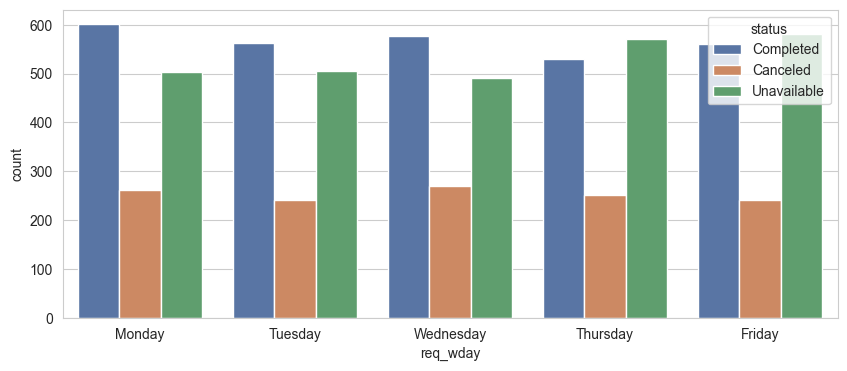

In [56]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="req_wday", hue="status")
plt.show()

In [57]:
rwday_status_ct = pd.crosstab(index=ub_df["req_wday"], columns=ub_df["status"]).reindex(weekdays)
rwday_status_ct

status,Canceled,Completed,Unavailable
req_wday,,,
Monday,262,601,504
Tuesday,240,562,505
Wednesday,270,577,490
Thursday,252,530,571
Friday,240,561,580


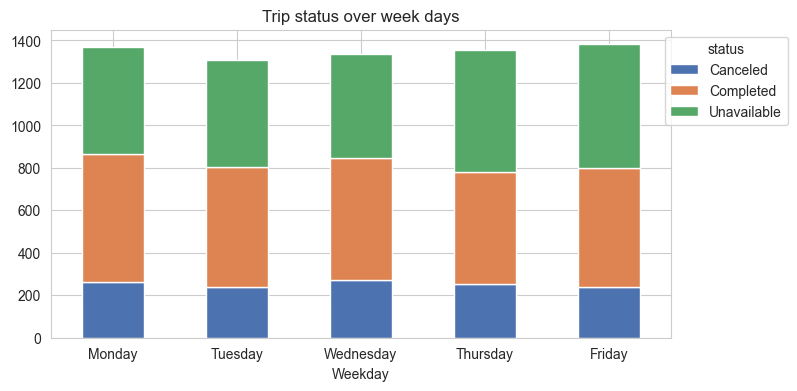

In [58]:
ax = rwday_status_ct.plot(kind="bar", stacked=True, figsize=(8, 4))
ax.legend(title="status", loc="upper right", bbox_to_anchor=(1.2, 1))

plt.title("Trip status over week days")
plt.xlabel("Weekday")
plt.xticks(rotation=0)

plt.show()

#### Features `req_wday` vs `pickup`

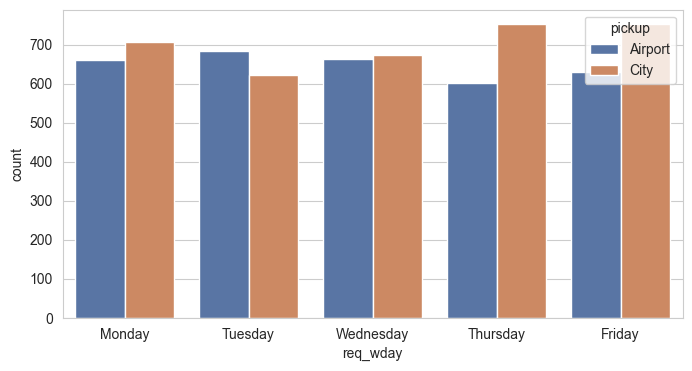

In [59]:
plt.figure(figsize=(8, 4))
sns.countplot(data=ub_df, x="req_wday", hue="pickup")
plt.show()

#### Features `req_hour` vs `status`

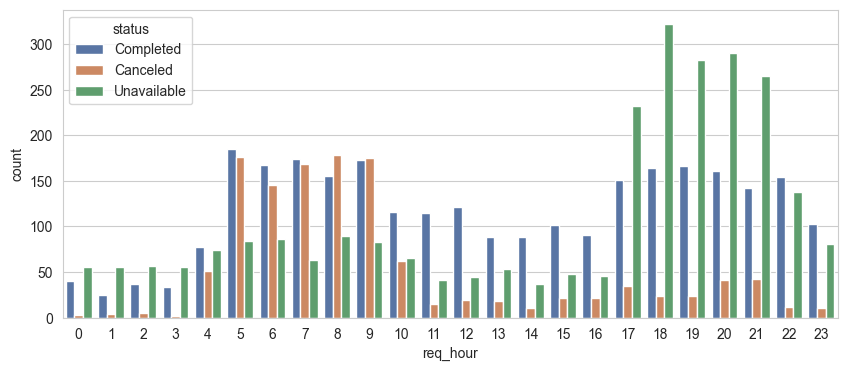

In [60]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="req_hour", hue="status")
plt.show()

In [61]:
rs_ct = pd.crosstab(index=ub_df["req_hour"], columns=ub_df["status"], normalize=True).round(2)
rs_ct

status,Canceled,Completed,Unavailable
req_hour,,,
0,0.00,0.01,0.01
1,0.00,0.00,0.01
2,0.00,0.01,0.01
3,0.00,0.01,0.01
4,0.01,0.01,0.01
5,0.03,0.03,0.01
6,0.02,0.02,0.01
7,0.03,0.03,0.01
8,0.03,0.02,0.01


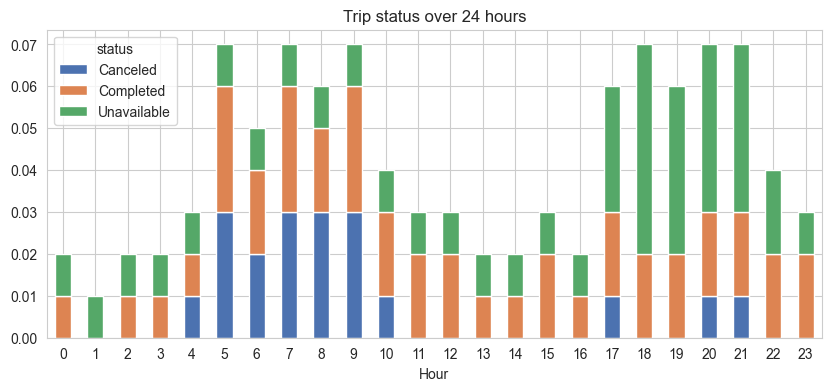

In [62]:
ax = rs_ct.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Trip status over 24 hours")
plt.xlabel("Hour")
plt.xticks(rotation=0)

plt.show()

#### Features `req_hour` vs `pickup`

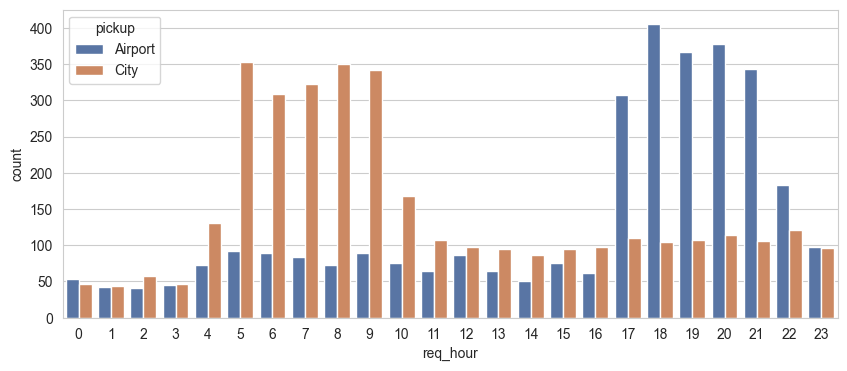

In [63]:
plt.figure(figsize=(10, 4))
sns.countplot(data=ub_df, x="req_hour", hue="pickup")
plt.show()

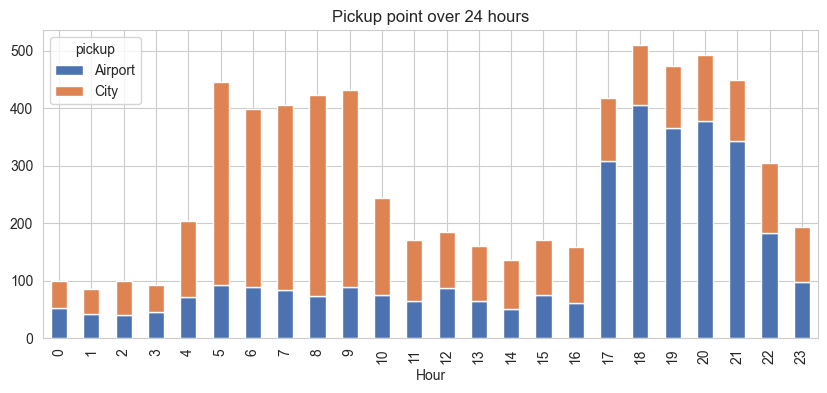

In [64]:
rp_ct = pd.crosstab(index=ub_df["req_hour"], columns=ub_df["pickup"])

ax = rp_ct.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Pickup point over 24 hours")
plt.xlabel("Hour")

plt.show()

#### Features `drp_date` vs `status`

In [65]:
# plt.figure(figsize=(6, 4))
# sns.countplot(data=ub_df, x="drp_date", hue="status")
# plt.show()

#### Features `drp_date` vs `pickup`

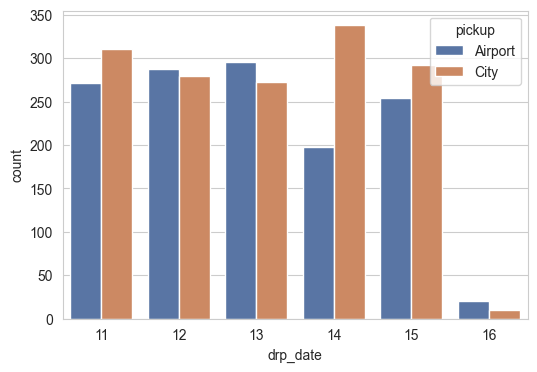

In [66]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="drp_date", hue="pickup")
plt.show()

#### Features `drp_wday` vs `pickup`

In [67]:
# plt.figure(figsize=(6, 4))
# sns.countplot(data=ub_df, x="drp_wday", hue="status")
# plt.show()

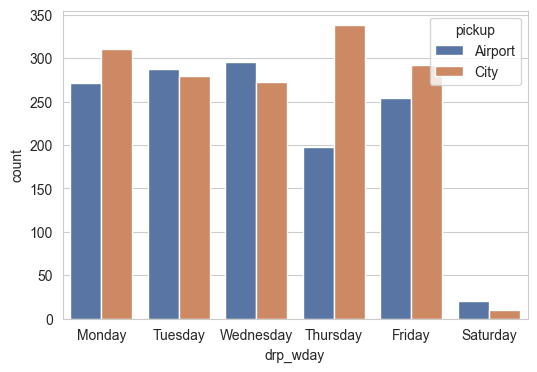

In [68]:
plt.figure(figsize=(6, 4))
sns.countplot(data=ub_df, x="drp_wday", hue="pickup")
plt.show()

#### Features `drp_hour` vs `status`

In [69]:
# plt.figure(figsize=(10, 4))
# sns.countplot(data=ub_df, x="drp_hour", hue="status")
# plt.show()

#### Features `drp_hour` vs `pickup`

In [70]:
# plt.figure(figsize=(10, 4))
# sns.countplot(data=ub_df, x="drp_hour", hue="pickup")
# plt.show()

#### Features `time_diff` vs `status`

In [71]:
# sns.histplot(x=ub_df["time_diff"].dt.total_seconds() / 60, hue=ub_df["status"], kde=True)
# plt.title("Trip time in minutes")
# plt.xlabel("Minutes")
# plt.show()

#### Features `time_diff` vs `pickup`

In [72]:
ub_df["time_diff"].dt.total_seconds().describe().to_frame().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
time_diff,2831.00,3144.83,831.04,1247.00,2460.00,3125.00,3840.00,4980.00


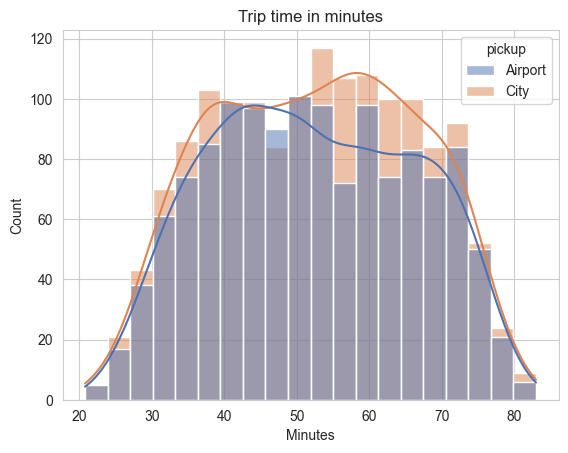

In [73]:
sns.histplot(x=ub_df["time_diff"].dt.total_seconds() / 60, hue=ub_df["pickup"], kde=True)
plt.title("Trip time in minutes")
plt.xlabel("Minutes")
plt.show()

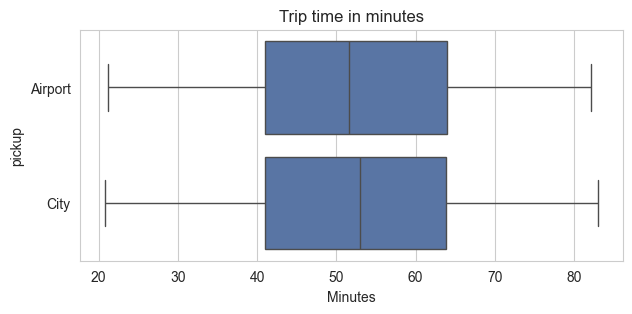

In [74]:
plt.figure(figsize=(7, 3))
sns.boxplot(x=ub_df["time_diff"].dt.total_seconds() / 60, y=ub_df["pickup"])
plt.title("Trip time in minutes")
plt.xlabel("Minutes")
plt.show()

## 7 Multivariate Analysis

#### Features `req_hour` vs `pickup` vs `status`

In [75]:
rhr_ps_ct = pd.crosstab(index=ub_df["req_hour"], columns=[ub_df["pickup"], ub_df["status"]])
rhr_ps_ct

pickup    Airport                           City                      
status   Canceled Completed Unavailable Canceled Completed Unavailable
req_hour                                                              
0               0        23          30        3        17          26
1               0        13          29        4        12          27
2               0        16          25        5        21          32
3               0        15          30        2        19          26
4               2        36          34       49        42          40
5               4        85           3      172       100          81
6               4        81           4      141        86          82
7               5        75           3      164        99          60
8               2        67           4      176        88          86
9               8        74           7      167        99          76
10              9        53          13       53        63          52
11              5        49          10       10        66          31
12             10        63          14        9        58          30
13              9        35          21        9        54          32
14              6        37           7        5        51          30
15             11        52          13       10        50          35
16             14        38           9        8        53          37
17             19        74         215       16        77          17
18             15        81         309        9        83          13
19             15        83         268        9        83          15
20             29        74         275       12        87          15
21             28        61         254       14        81          11
22              3        80         100        9        74          38
23              0        62          36       10        41          45

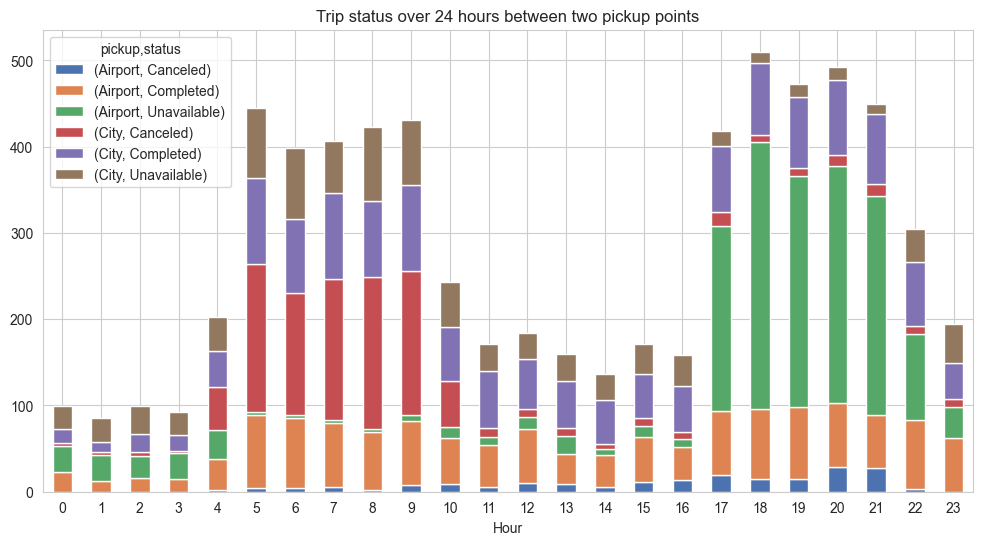

In [76]:
ax = rhr_ps_ct.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Trip status over 24 hours between two pickup points")
plt.xlabel("Hour")
plt.xticks(rotation=0)

plt.show()

#### Features `req_wday` vs `pickup` vs `status`

In [77]:
rwd_ps_ct = pd.crosstab(
    index=ub_df["req_wday"],
    columns=[ub_df["pickup"], ub_df["status"]],
).reindex(weekdays)
rwd_ps_ct

pickup     Airport                           City                      
status    Canceled Completed Unavailable Canceled Completed Unavailable
req_wday                                                               
Monday          42       281         338      220       320         166
Tuesday         45       289         350      195       273         155
Wednesday       48       298         317      222       279         173
Thursday        32       191         378      220       339         193
Friday          31       268         330      209       293         250

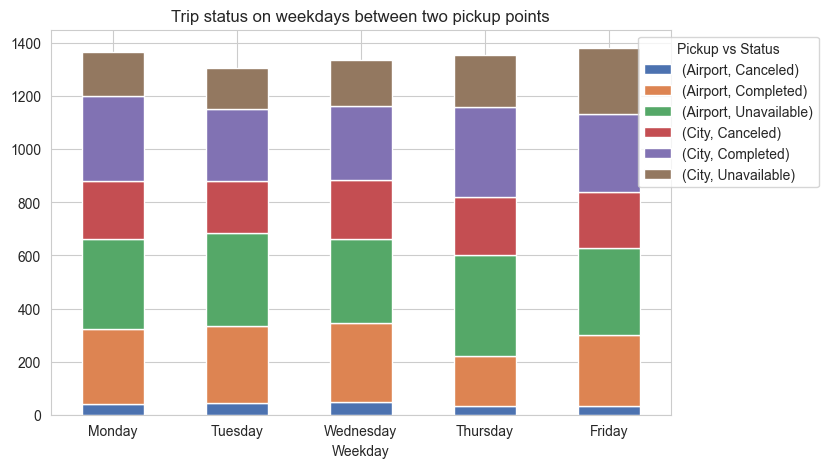

In [78]:
ax = rwd_ps_ct.plot(kind="bar", stacked=True, figsize=(8, 5))
ax.legend(title="Pickup vs Status", loc="upper right", bbox_to_anchor=(1.25, 1))

plt.title("Trip status on weekdays between two pickup points")
plt.xlabel("Weekday")
plt.xticks(rotation=0)

plt.show()

## 8 Root Cause Analysis